# 02 — Propensity score model

**Goal.** Decide which covariates belong in the model and why, then estimate P(treated | X) for
each control pool.

| | |
|---|---|
| **Reads** | `outputs/data/01_sample_cps.csv`, `01_sample_psid.csv` |
| **Writes** | `outputs/data/02_scored_cps.csv`, `02_scored_psid.csv` |

**Questions this notebook answers**

1. Did the handoff from notebook 01 survive the CSV?
2. **Which covariates belong in the model, and what is the argument for each one?**
3. What do the fitted propensity scores look like for each pool?

The two pools run as two parallel tracks and are never combined. CPS offers 15,992 candidate
controls and PSID only 2,490, and PSID respondents sit further from the participants on almost
every covariate. Keeping them separate is what makes the difficulty difference visible.

**What is deliberately *not* here.** Overlap, calipers, balance and the choice of matching scheme
all belong to notebook 03, because they are matching decisions and cannot be judged without
matching. This notebook stops at the score.

In [1]:
import sys
sys.path.insert(0, "..")

# Reload src/ modules automatically whenever they change on disk. Without this,
# Python caches the module on first import and later edits to src/*.py are
# invisible until you restart the kernel.
%load_ext autoreload
%autoreload 2

import json
import warnings

warnings.filterwarnings("ignore", message=".*numexpr.*")
warnings.filterwarnings("ignore", message=".*bottleneck.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

from src import psm, data, figures

pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:,.2f}".format)

POOLS = ["cps", "psid"]

%matplotlib inline

## 1. Did the handoff survive?

Notebook 01 hands its work over as CSV rather than in memory, so each stage can be re-run alone.
CSV has no type system, which means the dtypes chosen in notebook 01 do not make the trip.

In [2]:
samples = {pool: data.load_stage(f"01_sample_{pool}") for pool in POOLS}

raw_dtypes = data.load_raw("nsw_treated").dtypes
chk = pd.DataFrame({
    "as built in nb01": raw_dtypes,
    "after the CSV":    samples["cps"].dtypes,
}).astype(str)
chk["survived"] = chk["as built in nb01"] == chk["after the CSV"]
print(chk.to_string())

print("\nvalues are still only 0 and 1, so nothing is corrupted, only widened:")
for c in data.INDICATORS:
    print(f"  {c:10s} {sorted(samples['cps'][c].unique())}")

         as built in nb01 after the CSV  survived
treat                int8         int64     False
age               float64       float64      True
educ              float64       float64      True
black                int8         int64     False
hisp                 int8         int64     False
married              int8         int64     False
nodegree             int8         int64     False
re74              float64       float64      True
re75              float64       float64      True
re78              float64       float64      True

values are still only 0 and 1, so nothing is corrupted, only widened:
  treat      [0, 1]
  black      [0, 1]
  hisp       [0, 1]
  married    [0, 1]
  nodegree   [0, 1]


The five indicators left notebook 01 as `int8` and came back as `int64`. Nothing is broken — the
values are still `0` and `1` — but it is worth being precise about what happened: a CSV stores
`"0"` and pandas guesses a type on the way back in, and its guess is the widest safe one.

Re-narrowing is cheap and it keeps the two notebooks honest with each other. It also matters for a
reason that shows up later: `StandardScaler` and the solver both care about numeric types, and a
column silently changing width between stages is the kind of thing that makes two runs disagree
for no visible reason.

In [3]:
for pool, df in samples.items():
    df[data.INDICATORS] = df[data.INDICATORS].astype("int8")
    print(f"{pool:5s} {len(df):>6,} rows   treated {int(df.treat.sum()):>3d}"
          f"   treated share {df.treat.mean():>6.2%}   dtypes restored")

assert all(int(df.treat.sum()) == 185 for df in samples.values()), "treated arm must be 185 in both"
print("\nthe 185 treated rows are the same people in both samples; only the control pool differs")

cps   16,177 rows   treated 185   treated share  1.14%   dtypes restored
psid   2,675 rows   treated 185   treated share  6.92%   dtypes restored

the 185 treated rows are the same people in both samples; only the control pool differs


## 2. Two flags that notebook 01 deliberately did not build

Notebook 01 stops at the data as collected. `u74` and `u75` are the first thing built on top of it,
and they belong here rather than there because they are a modelling choice.

The reason they exist is the finding from notebook 01 section 4: **70.8% of participants report no
1974 earnings at all**, against 12.0% of CPS and 8.6% of PSID. A continuous dollar column cannot
express the difference between "earned very little" and "did not work". For this population that
distinction is not a detail — being out of work is close to the eligibility rule itself.

In [4]:
for pool, df in samples.items():
    samples[pool] = data.add_derived(df)

zero = pd.DataFrame({
    pool: {"n": len(df), "u74 = 1": int(df.u74.sum()), "u75 = 1": int(df.u75.sum()),
           "u74 among treated": int(df.loc[df.treat == 1, "u74"].sum()),
           "u74 among controls": int(df.loc[df.treat == 0, "u74"].sum())}
    for pool, df in samples.items()
}).T
print("the zero-earnings flags, in counts")
print(zero.to_string())
print("\n  note add_derived also builds employed78, a binary version of the outcome.")
print("  It is POST-treatment and never enters the model. See section 3.")

the zero-earnings flags, in counts
          n  u74 = 1  u75 = 1  u74 among treated  u74 among controls
cps   16177     2044     1859                131                1913
psid   2675      346      360                131                 215

  note add_derived also builds employed78, a binary version of the outcome.
  It is POST-treatment and never enters the model. See section 3.


## 3. Which covariates belong in the model, and why

This is the decision the whole estimate rests on, and it is the one that cannot be checked from
inside the analysis. So it gets an explicit argument rather than a default.

### The rule we are using

Matching is supposed to close the **backdoor paths** between treatment and outcome — the routes by
which the two groups differ for reasons that have nothing to do with the program. Closing them
requires knowing the causal structure, and nobody knows the full causal structure of a human life.

The practical substitute is the **disjunctive cause criterion**:

> Control for every observed variable that is a cause of the treatment, a cause of the outcome,
> or a cause of both.

It is a *disjunction* — "or", not "and" — so a variable earns its place by satisfying either
condition. The appeal is that it does not require the full graph. It requires only that you can
argue, variable by variable, for a causal role, which is something a person who knows the setting
can actually do.

Two things it does not do, and both matter here:

- It says nothing about causes you failed to *observe*. Those stay open, and no amount of careful
  covariate selection closes them.
- It can admit an **instrument** — a variable that causes treatment but has no effect on the
  outcome. Including one adds no bias reduction, inflates variance, and can amplify whatever bias
  unmeasured confounding is already causing. None of the ten below is plausibly a pure instrument:
  every one of them has a direct route to earnings. So the criterion is safe to apply here, but it
  is not safe everywhere.

### Applying it, one variable at a time

Each row below is an argument, not an observation. The justification is what a reader should
disagree with if they disagree with the design.

In [5]:
# The DAG declared as data. This single list drives both the figure and the table below,
# so the picture and the prose cannot drift apart.
DAG = [
    dict(name="age", causes_treatment=True, causes_outcome=True,
         why_treatment="eligibility strata were age-defined (17-20 year old dropouts)",
         why_outcome="earnings rise with labor market experience"),
    dict(name="educ", causes_treatment=True, causes_outcome=True,
         why_treatment="the dropout stratum required no completed schooling",
         why_outcome="human capital: each year of schooling raises earnings"),
    dict(name="nodegree", causes_treatment=True, causes_outcome=True,
         why_treatment="same eligibility route as educ; a credential is what the stratum lacked",
         why_outcome="employers screen on the credential, not only on years"),
    dict(name="black", causes_treatment=True, causes_outcome=True,
         why_treatment="recruitment sites reached this population differentially",
         why_outcome="labor market discrimination depresses earnings"),
    dict(name="hisp", causes_treatment=True, causes_outcome=True,
         why_treatment="recruitment sites reached this population differentially",
         why_outcome="labor market discrimination depresses earnings"),
    dict(name="married", causes_treatment=True, causes_outcome=True,
         why_treatment="the AFDC stratum was women with dependent children",
         why_outcome="household structure shifts labor supply and reservation wage"),
    dict(name="re74", causes_treatment=True, causes_outcome=True,
         why_treatment="eligibility required long-term detachment from work",
         why_outcome="earnings are highly persistent year to year"),
    dict(name="re75", causes_treatment=True, causes_outcome=True,
         why_treatment="eligibility required long-term detachment from work",
         why_outcome="earnings are highly persistent year to year"),
    dict(name="u74", causes_treatment=True, causes_outcome=True,
         why_treatment="not working at all is nearer the eligibility rule than any dollar amount",
         why_outcome="a year out of the labor market scars later earnings"),
    dict(name="u75", causes_treatment=True, causes_outcome=True,
         why_treatment="not working at all is nearer the eligibility rule than any dollar amount",
         why_outcome="a year out of the labor market scars later earnings"),
]

tbl = pd.DataFrame(DAG).set_index("name")
tbl.columns = ["-> treatment", "-> outcome", "why it causes treatment", "why it causes the outcome"]
print(f"{len(DAG)} covariates, every one a cause of treatment AND of the outcome\n")
for n, r in tbl.iterrows():
    print(f"  {n:9s} T: {r['why it causes treatment']}")
    print(f"  {'':9s} Y: {r['why it causes the outcome']}")

# The DAG is ordered for reading (nodegree sits beside educ, which it is derived from).
# The model uses the stored spec's column order, so the two are checked as sets.
assert {c["name"] for c in DAG} == set(data.covariate_spec("with_earnings")), \
    "the DAG and the stored spec must select the same covariates"
COVARIATES = data.covariate_spec("with_earnings")
print(f"\nmatches data.covariate_spec('with_earnings'):\n  {COVARIATES}")

10 covariates, every one a cause of treatment AND of the outcome

  age       T: eligibility strata were age-defined (17-20 year old dropouts)
            Y: earnings rise with labor market experience
  educ      T: the dropout stratum required no completed schooling
            Y: human capital: each year of schooling raises earnings
  nodegree  T: same eligibility route as educ; a credential is what the stratum lacked
            Y: employers screen on the credential, not only on years
  black     T: recruitment sites reached this population differentially
            Y: labor market discrimination depresses earnings
  hisp      T: recruitment sites reached this population differentially
            Y: labor market discrimination depresses earnings
  married   T: the AFDC stratum was women with dependent children
            Y: household structure shifts labor supply and reservation wage
  re74      T: eligibility required long-term detachment from work
            Y: earnings are hi

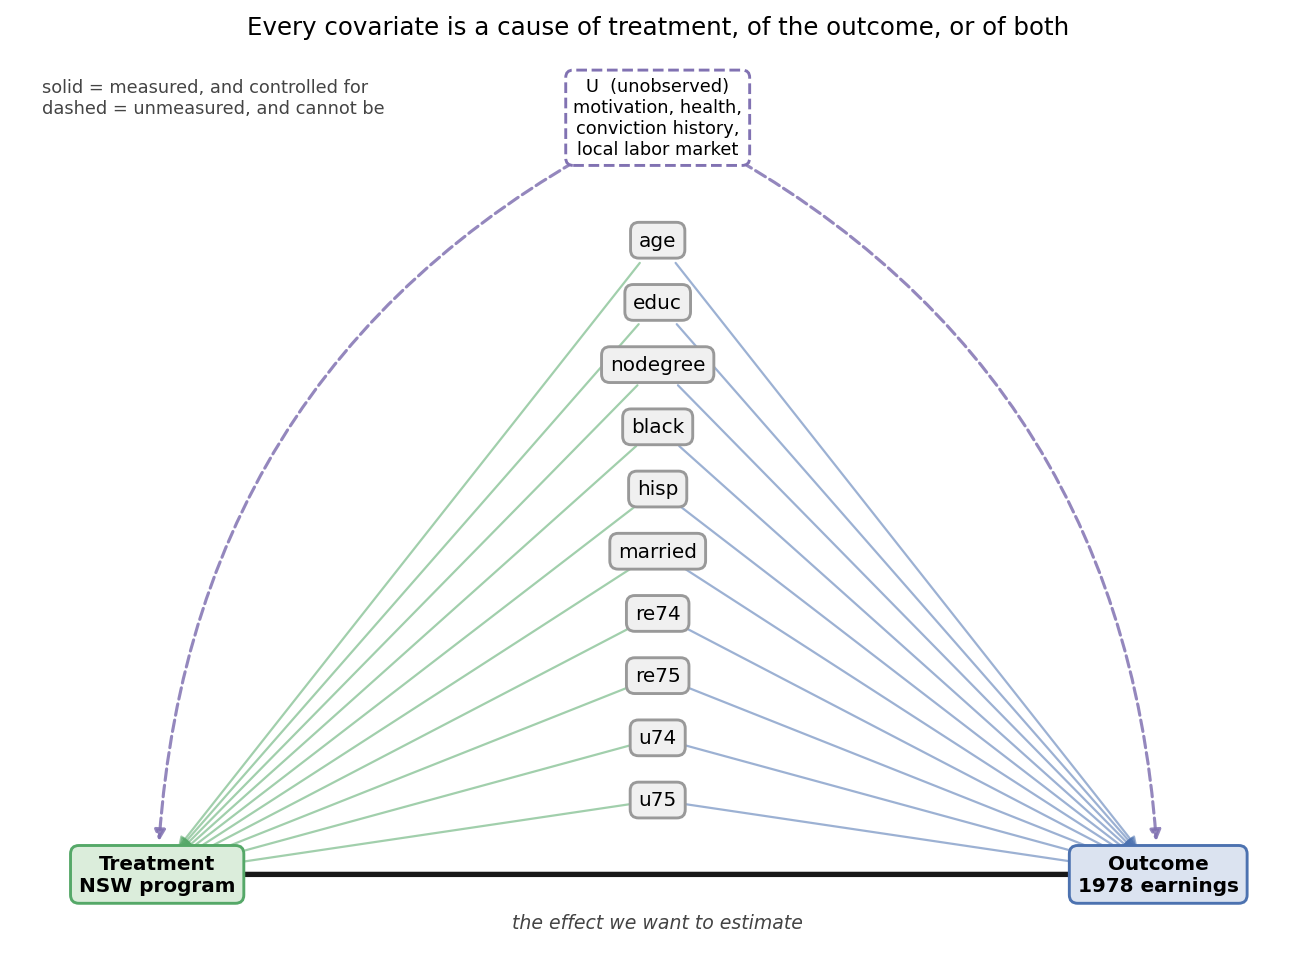

In [6]:
figures.dag_plot(
    DAG, "dag",
    title="Every covariate is a cause of treatment, of the outcome, or of both",
)
from IPython.display import Image
Image(filename="../outputs/figures/psm_dag.png")

### What the picture is telling you

Every solid arrow points **into** treatment or outcome. Nothing points out of them, and that is
not decoration — it is the claim being made. A variable with an arrow *from* treatment would be a
consequence of the program, and conditioning on it would destroy the estimate.

The dashed box is the honest part. **Motivation, health, addiction or conviction history, and the
local labor market are causes of both arms, and none of them is in the file.** The criterion covers
observed causes; these are not observed. So the backdoor is narrowed, not closed, and every
estimate downstream is conditional on those arrows being weak. Nothing in the analysis can tell us
whether they are. That is the whole reason this project runs on data where the answer is known.

### What is excluded, and why

- **`re78` is the outcome.** It never enters the model, a balance check, or a covariate
  specification. Conditioning on the outcome builds the answer into the design.
- **`employed78` is post-treatment.** `data.add_derived` builds it, and it stays out. It sits
  *downstream* of the program on the graph, which makes it a **mediator**: part of how the program
  raises earnings is by getting people employed at all. Conditioning on a mediator removes exactly
  the part of the effect you are trying to measure.

The general rule is easier to remember than the special cases: **nothing measured after treatment
may be a covariate.** Every one of the ten above was measured before anyone was assigned.

## 4. Fitting the model

One logistic regression per pool: participants against CPS, and participants against PSID. Two
separate fits, never one pooled fit. The 185 treated rows are identical in both, so any difference
between the two models is a difference between the control pools, which is exactly what we want to
be able to read.

### Why plain logistic regression, with no penalty

`scikit-learn`'s `LogisticRegression` does **not** fit a plain logistic regression by default. It
fits a **penalized** one. Worth unpacking, because the default is silent.

An ordinary logistic regression picks the coefficients β that best fit the observed treatment
labels. A penalized one minimizes something else:

$$-\log\mathcal{L}(\beta) \;+\; \frac{1}{C}\sum_j \beta_j^2$$

That second term is the **L2 penalty**: the sum of squared coefficients. It is a fine for having
large coefficients, so every β gets pulled toward zero. (The L1 alternative, $\sum_j|\beta_j|$,
pushes some coefficients to *exactly* zero and performs feature selection. L2 shrinks all of them
smoothly instead.)

**`C` is the inverse penalty strength, which runs backwards from intuition:**

| `C` | penalty weight `1/C` | effect |
|---|---|---|
| 0.01 | 100 | heavy fine — coefficients squashed toward zero |
| 1.0 | 1 | moderate — **scikit-learn's default** |
| 10⁶ | 0.000001 | negligible — plain, unpenalized logistic regression |

So a **bigger** `C` means **less** regularization.

**Why we want none of it here.** Regularization exists to stop a model chasing noise in its
training data so that it generalizes to data it has not seen. That is a prediction problem. This is
not one. No one will ever apply this model to a new person. Its only job is to produce a number
such that, once we condition on it, the covariate distributions of the two groups line up.

Shrinking the coefficients toward zero makes the score weigh each covariate *less* — which is
precisely what makes it *less* able to equalize them. The criterion for a propensity model is
balance, never accuracy and never AUC.

`psm.NO_PENALTY` is 10⁶ rather than `penalty=None` for a boring reason: that keyword's spelling
changed across scikit-learn versions (`'none'` in 1.0–1.3, `None` from 1.2), and a large `C` works
in all of them. The two agree to seven decimal places.

The evidence that this actually produces better balance needs matching to measure, so it lives in
notebook 03.

In [7]:
scored, models = {}, {}
for pool, df in samples.items():
    X, t = df[COVARIATES], df.treat.values
    ps = psm.fit_propensity(X, t, model="logit")     # unpenalized: C defaults to psm.NO_PENALTY
    df = df.copy()
    df["prop_score"] = ps
    scored[pool] = df
    models[pool] = ps
    print(f"{pool:5s} fitted on {len(df):>6,} rows, {len(COVARIATES)} covariates, C = {psm.NO_PENALTY:,.0f}")

cps   fitted on 16,177 rows, 10 covariates, C = 1,000,000
psid  fitted on  2,675 rows, 10 covariates, C = 1,000,000


In [8]:
coefs = {}
for pool, df in scored.items():
    X, t = df[COVARIATES], df.treat.values
    clf = LogisticRegression(C=psm.NO_PENALTY, max_iter=2000).fit(
        StandardScaler().fit_transform(X), t)
    coefs[pool] = pd.Series(clf.coef_[0], index=COVARIATES)

co = pd.DataFrame(coefs).round(2)
co["|larger|"] = co.abs().max(axis=1)
print("coefficients on STANDARDIZED covariates, so magnitudes are comparable across columns")
print(co.sort_values("|larger|", ascending=False).drop(columns="|larger|").to_string())

coefficients on STANDARDIZED covariates, so magnitudes are comparable across columns
           cps  psid
re75     -1.65 -3.83
black     1.18  1.19
age      -0.20 -1.11
u74       0.52  1.09
married  -0.45 -0.61
re74      0.60  0.31
hisp      0.47  0.39
u75       0.07 -0.47
nodegree  0.41  0.30
educ      0.06 -0.04


`re75` carries the largest coefficient in both pools, and by a wide margin. That is the DAG's
strongest arrow showing up in the fit: eligibility was effectively defined by not having worked, so
1975 earnings is close to being the assignment rule itself.

The sign is negative — more 1975 earnings, lower probability of being a participant — which is the
direction the design predicts. A positive sign here would have meant something was wrong.

In [9]:
dist = {}
for pool, df in scored.items():
    ps, t = df.prop_score, df.treat == 1
    dist[pool] = {
        "treated mean":  ps[t].mean(),   "control mean":  ps[~t].mean(),
        "treated min":   ps[t].min(),    "treated max":   ps[t].max(),
        "control min":   ps[~t].min(),   "control max":   ps[~t].max(),
    }
print("fitted propensity scores by arm")
# .to_string with an explicit float_format, because the notebook-wide display option
# rounds to 2 decimals and the interesting part of this table is near zero
print(pd.DataFrame(dist).T.to_string(float_format=lambda v: f"{v:.5f}"))

print("\ncontrols the model rates as likely participants:")
for pool, df in scored.items():
    c0 = df.loc[df.treat == 0, "prop_score"]
    print(f"  {pool:5s} {int((c0 > 0.5).sum()):>3d} of {len(c0):,} score above 0.5"
          f"   |   {int((c0 < 0.001).sum()):>6,} score below 0.001")

fitted propensity scores by arm
      treated mean  control mean  treated min  treated max  control min  control max
cps        0.32171       0.00785      0.00051      0.63336      0.00000      0.63751
psid       0.68483       0.02342      0.00028      0.99023      0.00000      0.98653

controls the model rates as likely participants:
  cps    50 of 15,992 score above 0.5   |   11,200 score below 0.001
  psid   23 of 2,490 score above 0.5   |    1,555 score below 0.001


In [10]:
print("AUC - a sanity check, NOT an objective\n")
for pool, df in scored.items():
    auc = roc_auc_score(df.treat, df.prop_score)
    print(f"  {pool:5s} AUC = {auc:.3f}   (treated are {df.treat.mean():.2%} of this sample)")

AUC - a sanity check, NOT an objective

  cps   AUC = 0.974   (treated are 1.14% of this sample)
  psid  AUC = 0.981   (treated are 6.92% of this sample)


### Reading the AUC

0.97 and 0.98. On a prediction problem those would be excellent numbers. Here they are a warning,
and it is worth being clear about why, because the instinct to celebrate a high AUC is strong.

AUC measures how well the model **separates** participants from survey respondents. A score near 1
means the two groups are almost perfectly distinguishable from their covariates alone — that
knowing someone's age, schooling and prior earnings is nearly enough to say which group they came
from.

That is bad news for matching. Matching needs the opposite: control units whose covariates make
them *plausible* participants. If the model can tell the groups apart almost perfectly, then very
few respondents look anything like a participant, and the ones we end up matching to are being
drawn from a thin sliver of the pool.

The score table two cells up says the same thing in people rather than in area-under-a-curve:
**11,200 of 15,992 CPS respondents score below 0.001**, and 1,555 of 2,490 in PSID. Seventy percent
of the CPS pool is not a plausible comparison for anyone in the program. The pool is nominally
15,992 candidates; in practice it is a few thousand, and the usable part is smaller still.

So the AUC is reported here as a **property of the data**, not a score for the model. A propensity
model with a low AUC would mean the two groups were genuinely similar, which is the easy case. We
do not have the easy case. Whether there are enough comparable controls to work with is the
question notebook 03 opens with, and this is the first hint of what it will find.

## 5. Hand off to notebook 03

The scored samples carry the covariates, the treatment indicator, the outcome, and `prop_score`.
Matching, calipers and balance start from here.

In [11]:
for pool, df in scored.items():
    keep = ["treat"] + COVARIATES + ["re78", "prop_score"]
    path = data.save_stage(df[keep], f"02_scored_{pool}")
    print(f"{path.name:22s} {df.shape[0]:>6,} rows x {len(keep)} cols   "
          f"treated {int(df.treat.sum())}   ps range [{df.prop_score.min():.5f}, {df.prop_score.max():.3f}]")

02_scored_cps.csv      16,177 rows x 13 cols   treated 185   ps range [0.00000, 0.638]
02_scored_psid.csv      2,675 rows x 13 cols   treated 185   ps range [0.00000, 0.990]
